In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("C:/Users/HP/Documents/Machine Learning/02_GOLD_price/financial_regression.csv")
df.head(5)

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
df.isnull().sum()

date                     0
sp500 open             185
sp500 high             185
sp500 low              185
sp500 close            185
sp500 volume           185
sp500 high-low         185
nasdaq open            185
nasdaq high            185
nasdaq low             185
nasdaq close           185
nasdaq volume          185
nasdaq high-low        185
us_rates_%            3728
CPI                   3728
usd_chf                210
eur_usd                210
GDP                   3847
silver open            185
silver high            185
silver low             185
silver close           185
silver volume          185
silver high-low        185
oil open               185
oil high               185
oil low                185
oil close              185
oil volume             185
oil high-low           185
platinum open          185
platinum high          185
platinum low           185
platinum close         185
platinum volume        185
platinum high-low      185
palladium open         185
p

In [4]:
df = df.drop(labels = ['us_rates_%', 'CPI', 'GDP'], axis = 1)

In [5]:
df.isnull().sum()

date                    0
sp500 open            185
sp500 high            185
sp500 low             185
sp500 close           185
sp500 volume          185
sp500 high-low        185
nasdaq open           185
nasdaq high           185
nasdaq low            185
nasdaq close          185
nasdaq volume         185
nasdaq high-low       185
usd_chf               210
eur_usd               210
silver open           185
silver high           185
silver low            185
silver close          185
silver volume         185
silver high-low       185
oil open              185
oil high              185
oil low               185
oil close             185
oil volume            185
oil high-low          185
platinum open         185
platinum high         185
platinum low          185
platinum close        185
platinum volume       185
platinum high-low     185
palladium open        185
palladium high        185
palladium low         185
palladium close       185
palladium volume      185
palladium hi

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df.drop(columns=['date'], inplace=True)

In [7]:
df.isnull().sum()

sp500 open            185
sp500 high            185
sp500 low             185
sp500 close           185
sp500 volume          185
sp500 high-low        185
nasdaq open           185
nasdaq high           185
nasdaq low            185
nasdaq close          185
nasdaq volume         185
nasdaq high-low       185
usd_chf               210
eur_usd               210
silver open           185
silver high           185
silver low            185
silver close          185
silver volume         185
silver high-low       185
oil open              185
oil high              185
oil low               185
oil close             185
oil volume            185
oil high-low          185
platinum open         185
platinum high         185
platinum low          185
platinum close        185
platinum volume       185
platinum high-low     185
palladium open        185
palladium high        185
palladium low         185
palladium close       185
palladium volume      185
palladium high-low    185
gold open   

In [8]:
# drop the rows which are completely empty exccept for the date
empty_feature_rows = df.drop(columns=['year', 'month', 'day', 'day_of_week']).isna().all(axis=1)
print("Rows with only date and no data:", empty_feature_rows.sum())
df = df[~df.drop(columns=['year', 'month', 'day', 'day_of_week']).isna().all(axis=1)]
df.isnull().sum()

Rows with only date and no data: 168


sp500 open            17
sp500 high            17
sp500 low             17
sp500 close           17
sp500 volume          17
sp500 high-low        17
nasdaq open           17
nasdaq high           17
nasdaq low            17
nasdaq close          17
nasdaq volume         17
nasdaq high-low       17
usd_chf               42
eur_usd               42
silver open           17
silver high           17
silver low            17
silver close          17
silver volume         17
silver high-low       17
oil open              17
oil high              17
oil low               17
oil close             17
oil volume            17
oil high-low          17
platinum open         17
platinum high         17
platinum low          17
platinum close        17
platinum volume       17
platinum high-low     17
palladium open        17
palladium high        17
palladium low         17
palladium close       17
palladium volume      17
palladium high-low    17
gold open             17
gold high             17


In [9]:
# Replace the remaining null values with the mean
df = df.copy()
df.fillna(df.mean(), inplace=True)
df.isnull().sum()

sp500 open            0
sp500 high            0
sp500 low             0
sp500 close           0
sp500 volume          0
sp500 high-low        0
nasdaq open           0
nasdaq high           0
nasdaq low            0
nasdaq close          0
nasdaq volume         0
nasdaq high-low       0
usd_chf               0
eur_usd               0
silver open           0
silver high           0
silver low            0
silver close          0
silver volume         0
silver high-low       0
oil open              0
oil high              0
oil low               0
oil close             0
oil volume            0
oil high-low          0
platinum open         0
platinum high         0
platinum low          0
platinum close        0
platinum volume       0
platinum high-low     0
palladium open        0
palladium high        0
palladium low         0
palladium close       0
palladium volume      0
palladium high-low    0
gold open             0
gold high             0
gold low              0
gold close      

In [10]:
# Dataset analysis
print(df.shape)
print(df.info())
print(df.describe())

(3736, 47)
<class 'pandas.DataFrame'>
Index: 3736 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sp500 open          3736 non-null   float64
 1   sp500 high          3736 non-null   float64
 2   sp500 low           3736 non-null   float64
 3   sp500 close         3736 non-null   float64
 4   sp500 volume        3736 non-null   float64
 5   sp500 high-low      3736 non-null   float64
 6   nasdaq open         3736 non-null   float64
 7   nasdaq high         3736 non-null   float64
 8   nasdaq low          3736 non-null   float64
 9   nasdaq close        3736 non-null   float64
 10  nasdaq volume       3736 non-null   float64
 11  nasdaq high-low     3736 non-null   float64
 12  usd_chf             3736 non-null   float64
 13  eur_usd             3736 non-null   float64
 14  silver open         3736 non-null   float64
 15  silver high         3736 non-null   float64
 16  silver low 

<Axes: >

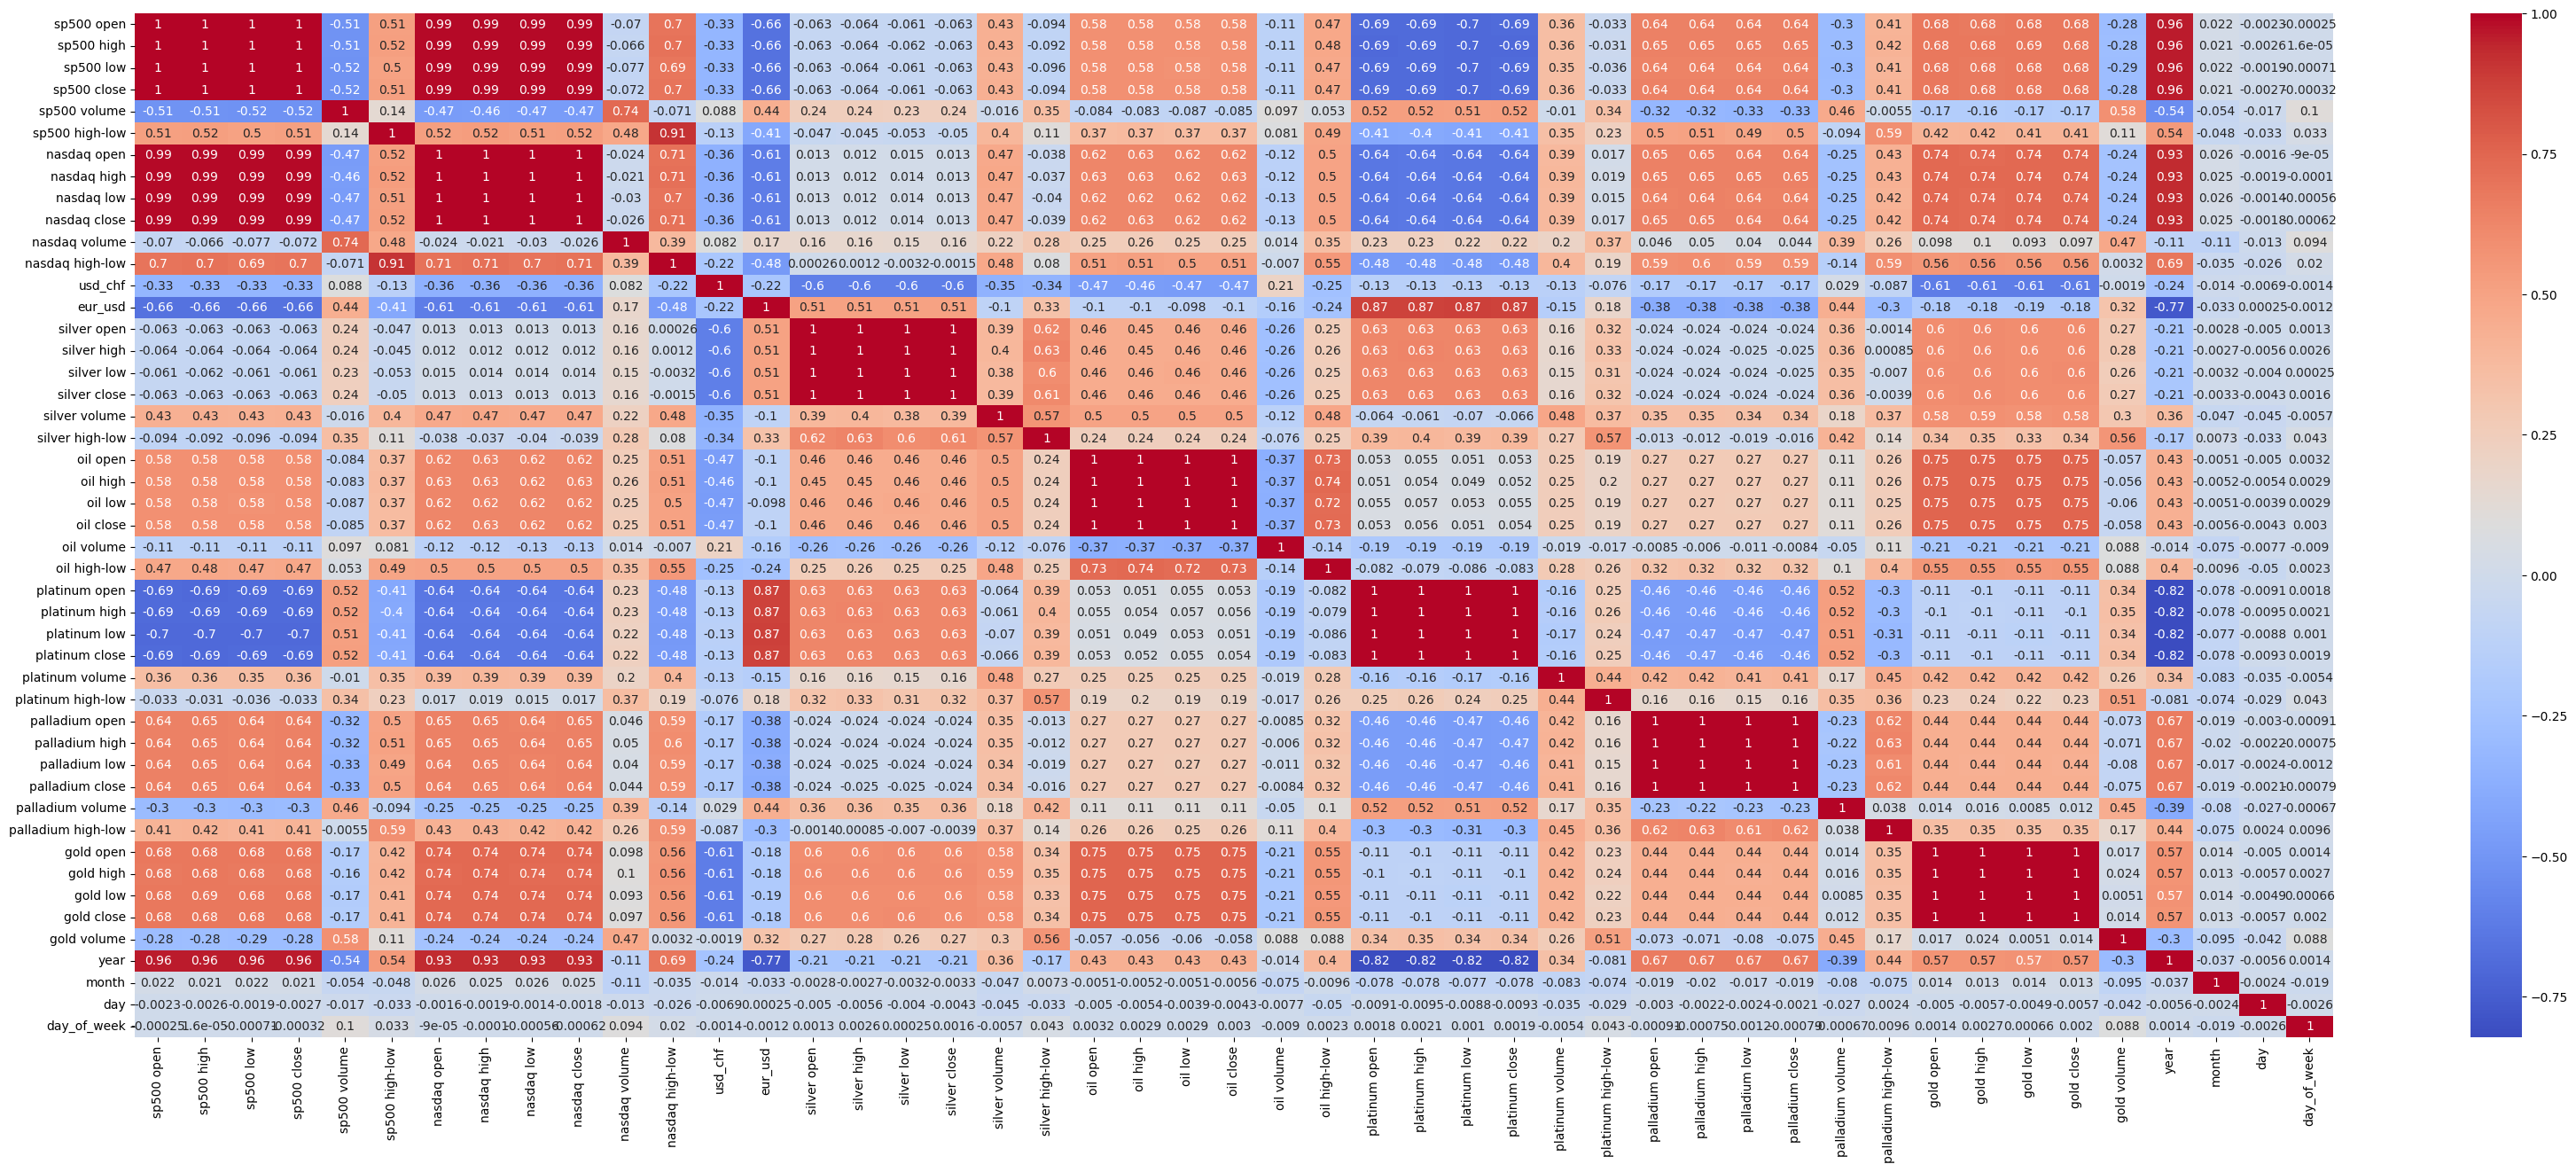

In [11]:
#display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr()
plt.figure(figsize = (40, 15))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

In [12]:
target = 'gold high'
corr_target = df.corr()[target].sort_values(ascending = False)
print(corr_target)

gold high             1.000000
gold open             0.999763
gold close            0.999743
gold low              0.999615
oil close             0.754128
oil high              0.753989
oil low               0.753890
oil open              0.753869
nasdaq high           0.736806
nasdaq open           0.736407
nasdaq close          0.736326
nasdaq low            0.735915
sp500 high            0.679919
sp500 close           0.679190
sp500 open            0.679174
sp500 low             0.678383
silver low            0.602635
silver close          0.602058
silver open           0.601710
silver high           0.601463
silver volume         0.586430
year                  0.568280
nasdaq high-low       0.559368
oil high-low          0.554446
palladium high        0.440258
palladium open        0.438780
palladium close       0.438294
palladium low         0.436607
platinum volume       0.422370
sp500 high-low        0.418188
palladium high-low    0.354457
silver high-low       0.349777
platinum

In [14]:
df.columns

Index(['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume',
       'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low',
       'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'usd_chf',
       'eur_usd', 'silver open', 'silver high', 'silver low', 'silver close',
       'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low',
       'oil close', 'oil volume', 'oil high-low', 'platinum open',
       'platinum high', 'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')

In [17]:
df = df.drop(['gold open', 'gold close', 'gold low', 'oil close','oil low', 'oil open','nasdaq open', 'nasdaq low',
       'nasdaq close', 'sp500 open','sp500 low', 'sp500 close','platinum open', 'platinum low', 'platinum close', 
              'platinum open', 'platinum low', 'platinum close'] , axis = 1 , errors = 'ignore')
df.columns

Index(['sp500 high', 'sp500 volume', 'sp500 high-low', 'nasdaq high',
       'nasdaq volume', 'nasdaq high-low', 'usd_chf', 'eur_usd', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil high', 'oil volume', 'oil high-low',
       'platinum high', 'platinum volume', 'platinum high-low',
       'palladium open', 'palladium high', 'palladium low', 'palladium close',
       'palladium volume', 'palladium high-low', 'gold high', 'gold volume',
       'year', 'month', 'day', 'day_of_week'],
      dtype='str')

In [18]:
df = df.drop(['silver open',  'silver low', 'silver close','palladium open',
       'palladium low', 'palladium close'], axis=1, errors = 'ignore')
df.columns

Index(['sp500 high', 'sp500 volume', 'sp500 high-low', 'nasdaq high',
       'nasdaq volume', 'nasdaq high-low', 'usd_chf', 'eur_usd', 'silver high',
       'silver volume', 'silver high-low', 'oil high', 'oil volume',
       'oil high-low', 'platinum high', 'platinum volume', 'platinum high-low',
       'palladium high', 'palladium volume', 'palladium high-low', 'gold high',
       'gold volume', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')

In [21]:
!pip install statsmodels

In [22]:
# Check for Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop('gold high', axis=1)
X = add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

               Feature           VIF
0                const  1.344320e+07
1           sp500 high  1.710381e+02
2         sp500 volume  6.622143e+00
3       sp500 high-low  9.630989e+00
4          nasdaq high  1.248970e+02
5        nasdaq volume  5.446139e+00
6      nasdaq high-low  1.241879e+01
7              usd_chf  3.742449e+00
8              eur_usd  8.041256e+00
9          silver high  6.333146e+00
10       silver volume  2.712410e+00
11     silver high-low  3.454439e+00
12            oil high  8.909145e+00
13          oil volume  1.343162e+00
14        oil high-low  3.036611e+00
15       platinum high  2.823642e+01
16     platinum volume  1.814360e+00
17   platinum high-low  2.190788e+00
18      palladium high  3.549410e+00
19    palladium volume  1.960219e+00
20  palladium high-low  2.429362e+00
21         gold volume  2.375393e+00
22                year  5.957820e+01
23               month  1.425125e+00
24                 day  1.016743e+00
25         day_of_week  1.030139e+00


In [23]:
# Drop features which have high Variance Inflation Factor (VIF)
df = df.drop(['sp500 high','nasdaq high','year','platinum high','nasdaq high-low'], axis = 1, errors = 'ignore')
print(df.columns) 

Index(['sp500 volume', 'sp500 high-low', 'nasdaq volume', 'usd_chf', 'eur_usd',
       'silver high', 'silver volume', 'silver high-low', 'oil high',
       'oil volume', 'oil high-low', 'platinum volume', 'platinum high-low',
       'palladium high', 'palladium volume', 'palladium high-low', 'gold high',
       'gold volume', 'month', 'day', 'day_of_week'],
      dtype='str')


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

x = df.drop('gold high', axis = 1)
y = df['gold high']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
x_scaled_train = scaler.fit_transform(x_train)
x_scaled_test = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_scaled_train, y_train)

y_pred = lr.predict(x_scaled_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-squared): {r2:.4f}")

MAE  (Mean Absolute Error): 8.6823
MSE  (Mean Squared Error): 133.7707
RMSE (Root Mean Squared Error): 11.5659
R²   (R-squared): 0.8450


In [29]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

x_poly_train = poly.fit_transform(x_scaled_train)
x_poly_test = poly.transform(x_scaled_test)

poly_reg = LinearRegression()
poly_reg.fit(x_poly_train, y_train)

y_pred = poly_reg.predict(x_poly_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error) : {mae: .4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-squared): {r2:.4f}")

MAE (Mean Absolute Error) :  3.8482
MSE  (Mean Squared Error): 34.9147
RMSE (Root Mean Squared Error): 5.9089
R²   (R-squared): 0.9596


In [30]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 100),  
    cv=5,                             
    random_state=42
)
lasso_cv.fit(x_scaled_train, y_train)

y_pred = lasso_cv.predict(x_scaled_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-squared): {r2:.4f}")

MAE  (Mean Absolute Error): 8.6689
MSE  (Mean Squared Error): 133.4689
RMSE (Root Mean Squared Error): 11.5529
R²   (R-squared): 0.8454


In [32]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 0.001)

ridge.fit(x_scaled_train, y_train)

y_pred = ridge.predict(x_scaled_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-squared): {r2:.4f}")

MAE  (Mean Absolute Error): 8.6823
MSE  (Mean Squared Error): 133.7707
RMSE (Root Mean Squared Error): 11.5659
R²   (R-squared): 0.8450


In [33]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(penalty='l2', alpha=0.01, max_iter=1000, learning_rate='invscaling', random_state=42)

sgd.fit(x_scaled_train, y_train)

y_pred = sgd.predict(x_scaled_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-squared): {r2:.4f}")

MAE  (Mean Absolute Error): 8.6762
MSE  (Mean Squared Error): 133.4707
RMSE (Root Mean Squared Error): 11.5530
R²   (R-squared): 0.8454
